In [1]:
import os
import copy
import itertools
import numpy as np
import scipy
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import Image
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# Implementing k-means

We will implement the k-means algorithm and test it on the "Iris" dataset of scikit-learn.

**Question 1**

The two main components of the k-means algorithm are:
1. `compute_clusters`: given the data and centroids, computes for each data point the cluster to which it belongs;
2. `update_centroids`: given the data, the cluster of each data point, and k, computes the new centroid of each cluster.

Implement these two functions.

In [2]:
def compute_clusters(X, centroids):
    n = X.shape[0]
    k = centroids.shape[0]
    distances = np.zeros((n, k))   # distances between each data point and each centroid
    for i, j in itertools.product(range(n), range(k)):
        distances[i, j] = np.linalg.norm(X[i] - centroids[j])
        
    return np.argmin(distances, axis = 1)

In [3]:
def update_centroids(X, clusters, k):
    p = X.shape[1]
    centroids = np.zeros((k, p))

    for cl in range(k):
        centroids[cl] = X[clusters == cl].mean(0)   # the new centroid is the barycenter of the data points belonging to the cluster

    return centroids

**Question 2**

Write the `kmeans` functions, which performs the full k-means algorithm.

Arguments:
* `X`: the dataset;
* `k`: the number of clusters;
* `init`: type of initialization of the algo, either equal to `random` or `forgy`:
  * `random`: assign a random cluster to each data point;
  * `forgy`: sample `k` data points and consider them as the initial centroids;
* `max_iter`: maximum number of iterations.

Returns:
* the centroids;
* the clusters;
* the number of iterations performed until convergence.

Note: find a way to check if the algorithm has converged early.

In [4]:
def kmeans(X, k, init = "random", max_iter = 100):
    n = X.shape[0]
    
    if init == "random":
        clusters = np.random.randint(k, size = n)
    elif init == "forgy":
        idx_centroids = np.random.choice(n, size = k, replace = False)
        centroids = X[idx_centroids]
        clusters = compute_clusters(X, centroids)
    else:
        raise ValueError(f"Unrecognized 'init': got {init}.")
        
    last_clusters = clusters
    for i in range(max_iter):
        centroids = update_centroids(X, clusters, k)
        clusters = compute_clusters(X, centroids)
        if np.all(clusters == last_clusters):
            break
        last_clusters = clusters

    return {"centroids": centroids,
           "clusters": clusters,
           "iteration": i}

**Question 3**

Plot the Iris dataset on a 2D figure (take 2 features out of the 4), with one color per class.

Perform k-means for $k \in \{2, \cdots, 9\}$ and plot the results on 8 subplots. In each figure, the data points belonging to different clusters should appear with different colors.

What do we observe with $k = 2$ and $k = 3$?

In [5]:
from sklearn.datasets import load_iris

iris_data = load_iris()
X = iris_data["data"]
y = iris_data["target"]
n = X.shape[0]

In [6]:
kmeans(X, 5, init = "forgy")

{'centroids': array([[5.53214286, 2.63571429, 3.96071429, 1.22857143],
        [5.006     , 3.428     , 1.462     , 0.246     ],
        [6.24722222, 2.84722222, 4.775     , 1.575     ],
        [6.52916667, 3.05833333, 5.50833333, 2.1625    ],
        [7.475     , 3.125     , 6.3       , 2.05      ]]),
 'clusters': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2,
        0, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 2, 2,
        0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 3, 2, 4, 3, 3, 4, 0, 4, 3, 4,
        3, 3, 3, 2, 3, 3, 3, 4, 4, 2, 3, 2, 4, 2, 3, 4, 2, 2, 3, 4, 4, 4,
        3, 2, 2, 4, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 2, 3, 3, 2]),
 'iteration': 7}

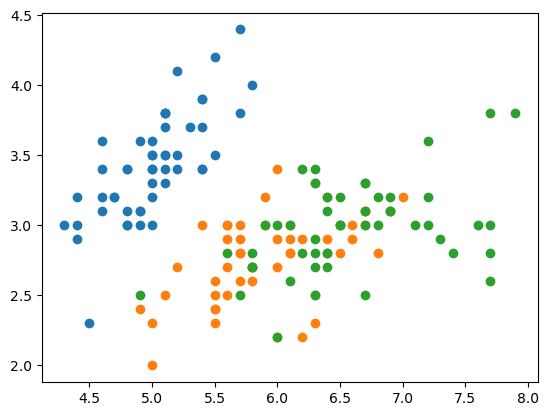

In [7]:
for cl in [0, 1, 2]:
    select = (y == cl)
    plt.scatter(X[select,0], X[select,1], label = f"Class {cl}")

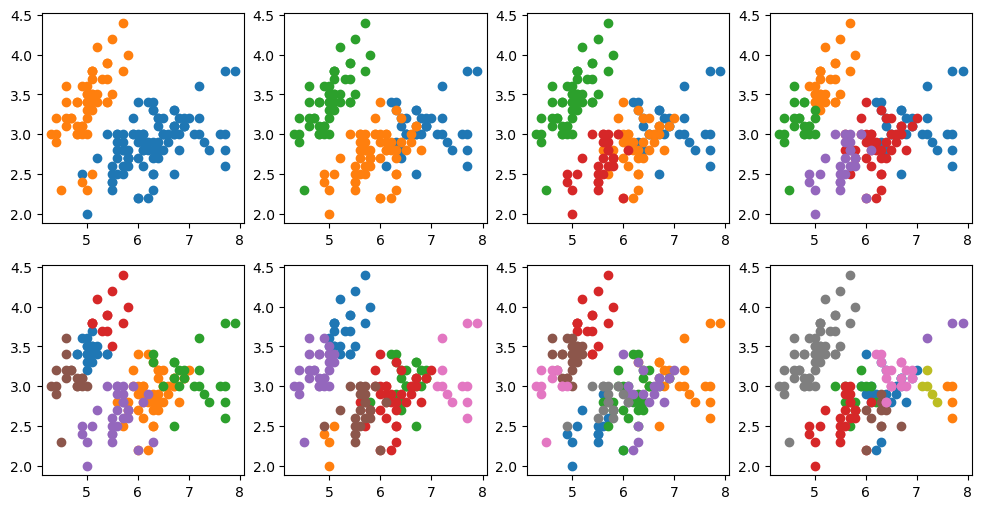

In [8]:
fig, ax = plt.subplots(2, 4, figsize=(12, 6))

for i, n_clusters in enumerate(range(2, 10)):
    lst_classes = list(range(n_clusters))
    dct = kmeans(X, n_clusters, init = "forgy")
    y_hat = dct["clusters"]

    for cl in lst_classes:
        select = (y_hat == cl)
        ax[i // 4, i % 4].scatter(X[select,0], X[select,1], label = f"Class {cl}")

**Answer**

With $k = 2$ and $k = 3$, we recover the main information contained in the Iris dataset: there are 3 species of Iris, and 2 of them are very close to each other.

# Stars clustering

How do the physicists classify the stars?

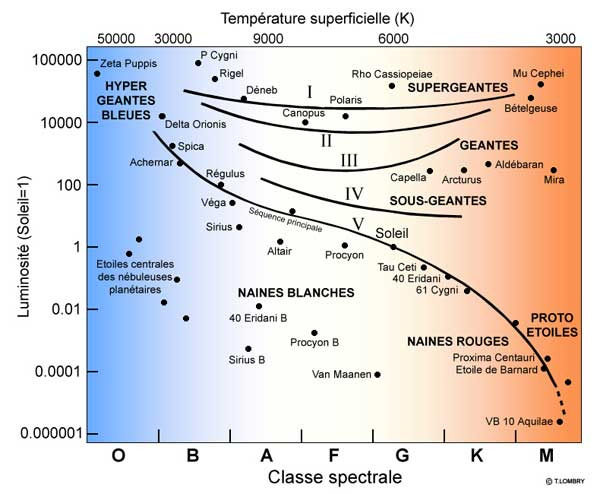

In [9]:
Image(filename = "etoiles-diagramme-hr.jpg")

In [10]:
Image(filename = "stars_3732_hrgenericsml_01.jpg")

In [11]:
df = pl.read_csv("stars_nasa_classification.csv")
df

Temperature,L,R,A_M,Color,Spectral_Class,Type
i64,f64,f64,f64,str,str,i64
3068,0.0024,0.17,16.12,"""Red""","""M""",0
3042,0.0005,0.1542,16.6,"""Red""","""M""",0
2600,0.0003,0.102,18.7,"""Red""","""M""",0
2800,0.0002,0.16,16.65,"""Red""","""M""",0
1939,0.000138,0.103,20.06,"""Red""","""M""",0
…,…,…,…,…,…,…
38940,374830.0,1356.0,-9.93,"""Blue""","""O""",5
30839,834042.0,1194.0,-10.63,"""Blue""","""O""",5
8829,537493.0,1423.0,-10.73,"""White""","""A""",5


**Question 1**

We want to make unsupervised learning on this dataset. We will focus on the numerical variables (Temperature, L, R, A_M) and the "class" (Type) to visualize the performance of our methods.

First, some variables should be pre-processed. Which ones? Why? Do the relevant transformations.

**Answer**

The variables Temperature, L and R are positive and take values in a range containing several orders of magnitude. This indicates that we should perform a logarithmic transform on them. The variable A_M can be kept as is.

In [12]:
var_names = ["Temperature", "L", "R", "A_M"]
vnames_logs = ["Temperature", "R", "L"]
vnames_lins = list(set(var_names) - set(vnames_logs))
target_name = "Type"

Xlin = df[var_names]

X = df.select(pl.col(vnames_logs).log())
X = X.with_columns(df[vnames_lins])
y = df[target_name]
classes = y.unique()

## Visualizing the dataset with a PCA

**Question 2**

We want to project the numerical features on a 2D space in order to visualize them on a 2D figure.

After doing the adequate transformation, perform the PCA on the data and make a scatter plot of the projected data. Use a different color for each class.

In [13]:
# Before doing a PCA, we should standardize the data (affine transformation to make each variable
# have mean 0 and variance 1). By doing so, we make each variable "weight the same" when doing the PCA.

Xstd = X.select((pl.all() - pl.all().mean()) / pl.all().std())

In [14]:
pca = PCA(n_components = 2)
Xpca = pca.fit_transform(Xstd)

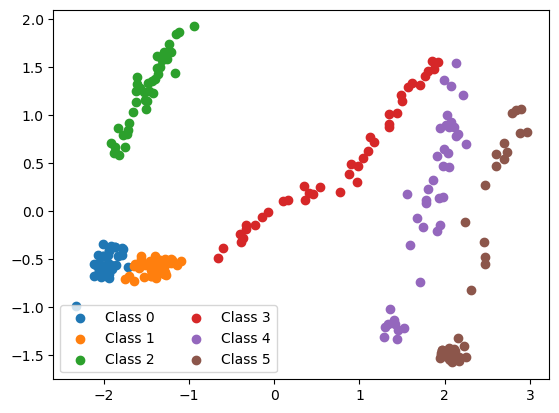

In [15]:
for cl in classes:
    select = (y.to_numpy() == cl)
    plt.scatter(Xpca[select,0], Xpca[select,1], label = f"Class {cl}")
    
plt.legend(ncol = 2)

Text(0.5, 1.0, 'Reconstitution of the initial figures')

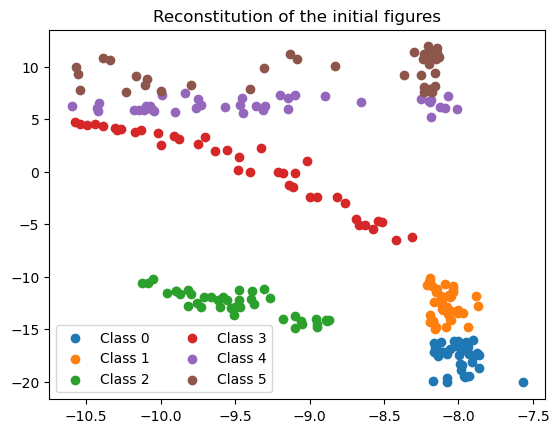

In [16]:
for cl in classes:
    select = (y.to_numpy() == cl)
    plt.scatter(-X["Temperature"].filter(select), -X["A_M"].filter(select), label = f"Class {cl}")
    
plt.legend(ncol = 2)
plt.title("Reconstitution of the initial figures")

## Clustering with k-means

**Question 3**

By using `sklearn.cluster.KMeans`, perform clustering on the dataset with $k \in \{2, \cdots 9\}$. Plot the results in the subspace given by the PCA, with one color for each class.

Do we recover the original classes? What do these figures tell us about the intrinsic structure of the dataset (without considering the true labels)?

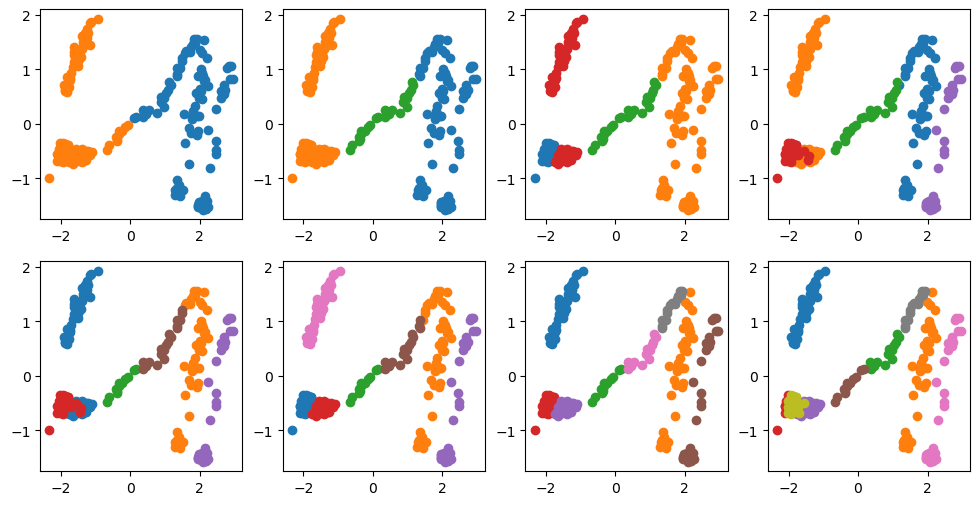

In [17]:
fig, ax = plt.subplots(2, 4, figsize=(12, 6))

for i, n_clusters in enumerate(range(2, 10)):
    lst_classes = list(range(n_clusters))
    kmeans = KMeans(n_clusters = n_clusters)

    kmeans.fit(X)
    y_hat = kmeans.predict(X)

    for cl in lst_classes:
        select = (y_hat == cl)
        ax[i // 4, i % 4].scatter(Xpca[select,0], Xpca[select,1], label = f"Class {cl}")

**Answer**

We do not recover exactly the original classes. With $k = 7$, we are very close to the original classes, but the central data points located on the diagonal are split into two classes.

We also observe that:
* a large bag of data points is split into two clusters starting from $k = 4$, which adds a lot of information compared to the plot of the 2D PCA; so, k-means can easily distinguish classes 0 and 1;
* class 3 is easily split into 2 clusters, showing that there is a lot of heterogeneity inside it;
* classes 1 and 2 and close to each other (k-means confounds them even for $k = 5$;
* k-means is able to distinguish classes 4 and 5, even if they are close and have a large variance along the same axis.

## Hierarchical clustering

In [18]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

**Question 4**

Perform hierarchical clustering with `AgglomerativeClustering`. Plot the dendogram with the function `plot_dendrogram` defined above.

In [19]:
agg = AgglomerativeClustering(distance_threshold = 0, n_clusters = None)

In [20]:
agg.fit(X)

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

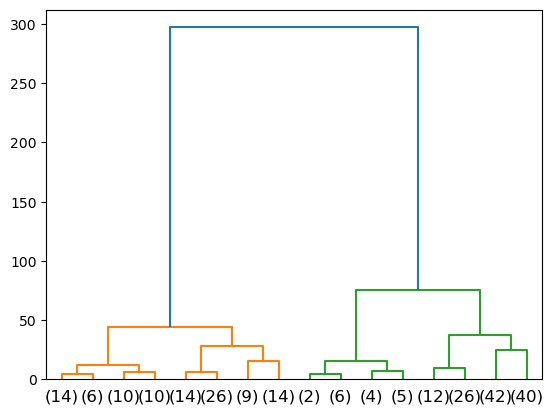

In [21]:
plot_dendrogram(agg, truncate_mode = "level", p = 3)

**Question 5**

Do again Question 3, but with `AgglomerativeClustering` instead of `KMeans`.

What do we observe?

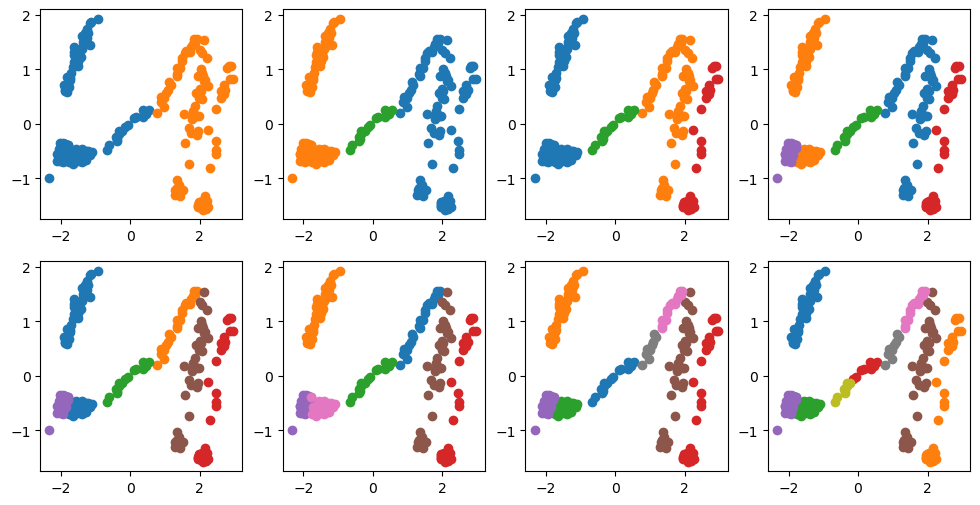

In [22]:
fig, ax = plt.subplots(2, 4, figsize=(12, 6))

for i, n_clusters in enumerate(range(2, 10)):
    lst_classes = list(range(n_clusters))
    
    agg = AgglomerativeClustering(n_clusters = n_clusters)
    y_hat = agg.fit_predict(X)

    for cl in lst_classes:
        select = (y_hat == cl)
        ax[i // 4, i % 4].scatter(Xpca[select,0], Xpca[select,1], label = f"Class {cl}")

**Answer**

Compared to k-means, the division in cluster is less noisy and more consistent. In particular, the clusters do appear or disappear by chance, depending on the initialization, which occurs with k-means.